> ### ⚠️ Select the **`Python 3 (croprow)`** kernel first
> This notebook runs in the isolated croprow env (Python **3.11**, numpy<2, OpenCV). If the first cell throws `ModuleNotFoundError: No module named 'cv2'`, the wrong interpreter is selected.
>
> **VSCode:** click **Select Kernel** (top-right of the notebook) -> **Jupyter Kernel** -> **`Python 3 (croprow)`**.
> - Not listed? Run **Developer: Reload Window** (Ctrl+Shift+P) and look again - the kernel is registered but VSCode may have cached the old list.
> - Or pick **Python Environments... -> Enter interpreter path...** and paste the venv python:
> ```
> croprow\.venv\Scripts\python.exe
> ```
> Do **not** use the repo-root `.venv` - that is the potato backend (Python 3.13, no cv2 by design).

# 02 - Verify labels visually

Draw the converted (polygon -> axis-aligned) boxes onto 20 random frames and display them inline. Boxes are derived on the fly straight from the source polygon labels, so this is an honest check of the conversion, independent of whether 01 has been run.

In [1]:
import os, sys
from pathlib import Path

# Locate repo root (holds croprow/utils.py) so `import croprow.utils` works
# regardless of the cwd the notebook is launched from.
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "croprow" / "utils.py").is_file()
)
sys.path.insert(0, str(REPO_ROOT))
from croprow import utils as U

# === CONFIG: the ONLY place to set the dataset location ===================
# Prefer the LETTUCE_ROOT env var. Otherwise edit LETTUCE_ROOT_DEFAULT below.
# (No absolute path is baked into utils.py -- it is supplied from here.)
LETTUCE_ROOT_DEFAULT = r"D:\croprow_dataset\LettuceMOTS"
LETTUCE_ROOT = os.environ.get("LETTUCE_ROOT", LETTUCE_ROOT_DEFAULT)
# ==========================================================================

root = U.resolve_lettuce_root(LETTUCE_ROOT)
DATA_DIR = REPO_ROOT / "croprow" / "data"
RESULTS_MD = REPO_ROOT / "croprow" / "RESULTS.md"
print("LETTUCE_ROOT :", root)
print("DATA_DIR     :", DATA_DIR)

%matplotlib inline
import random
import matplotlib.pyplot as plt

N_SHOW = 20
SEED = 7

LETTUCE_ROOT : D:\croprow_dataset\LettuceMOTS
DATA_DIR     : D:\sih26software\Crop_detection_management\croprow\data


## Sample 20 frames across all labeled sequences

In [2]:
all_frames = []
for s in U.labeled_sequences(root):
    all_frames.extend(img for img, _ in U.frame_pairs(root, s))
print("total labeled frames:", len(all_frames))

rng = random.Random(SEED)
sample = rng.sample(all_frames, min(N_SHOW, len(all_frames)))
print("showing", len(sample), "frames")

total labeled frames: 596
showing 20 frames


## Draw boxes and display inline

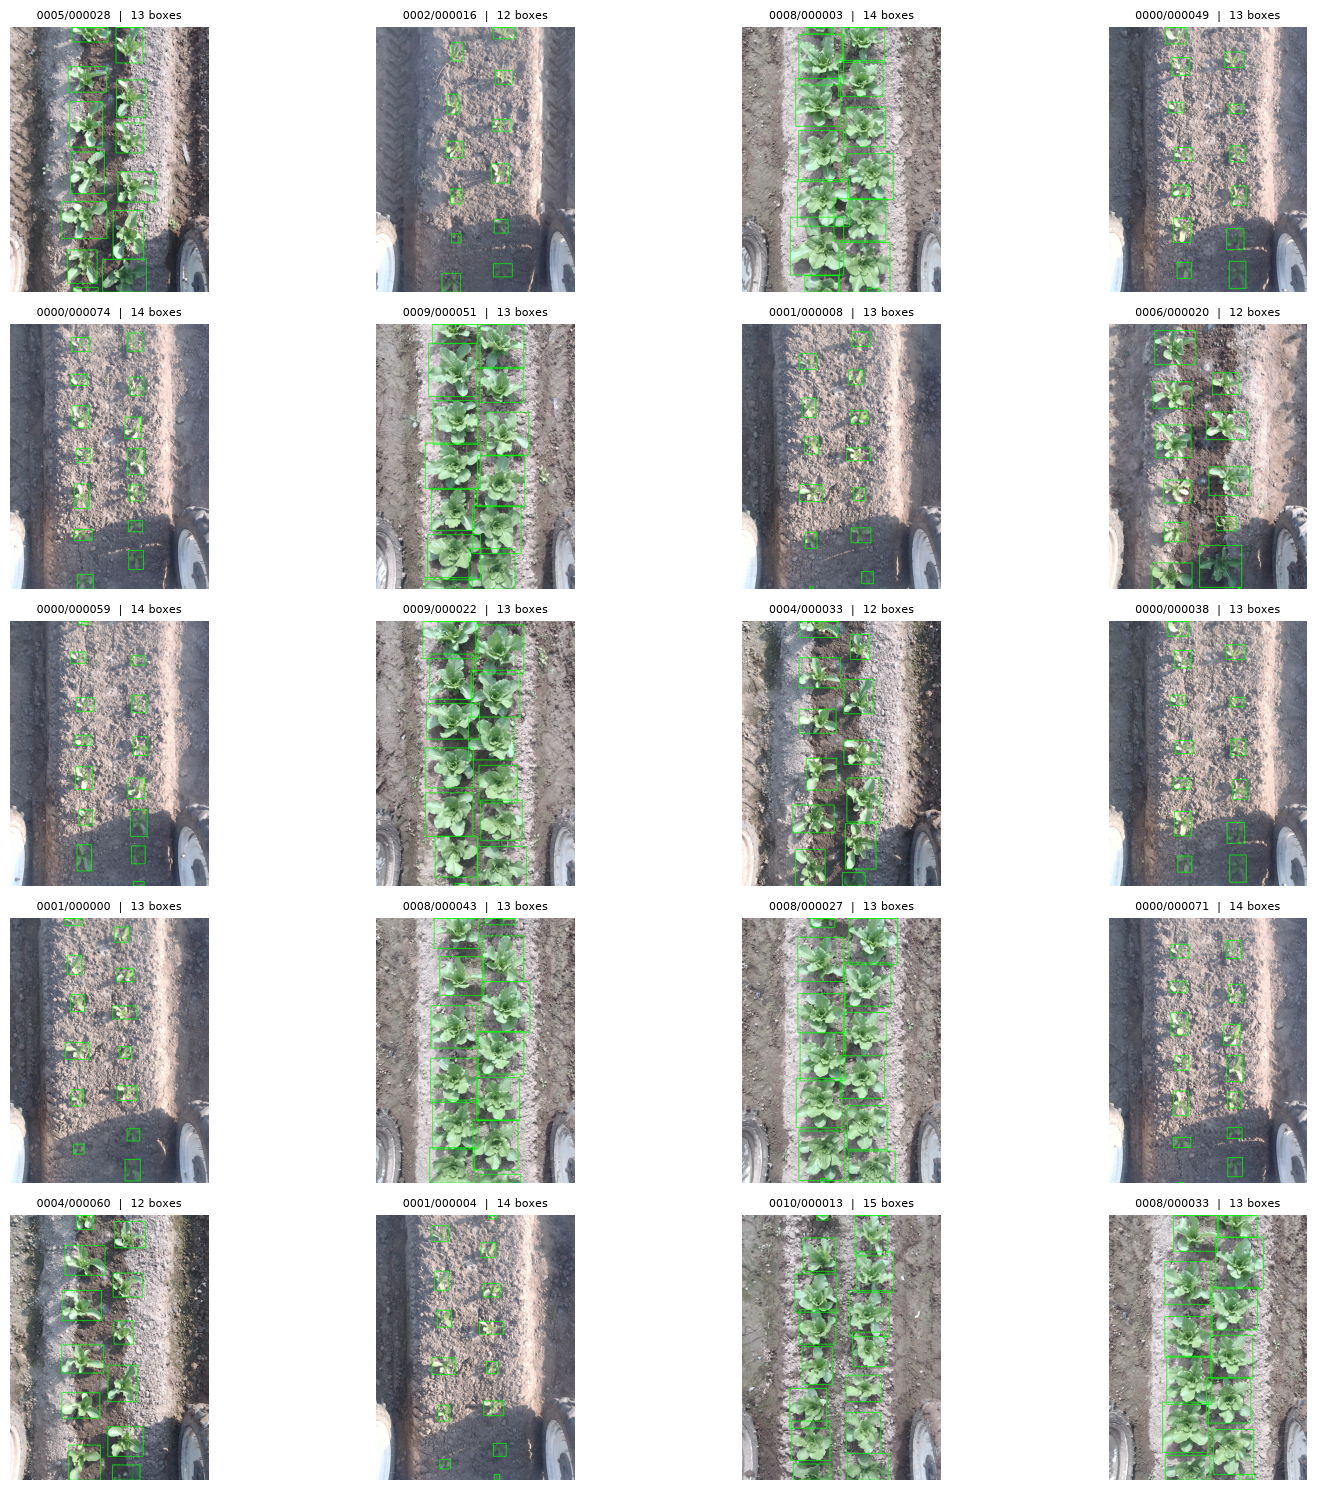

In [3]:
cols = 4
rows = (len(sample) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = axes.ravel()
for ax, img_path in zip(axes, sample):
    boxes = U.boxes_for_image(root, img_path)
    rgb = U.imread_rgb(img_path)
    drawn = U.draw_boxes(rgb, boxes, color=(0, 255, 0), thickness=2)
    ax.imshow(drawn)
    ax.set_title(f"{img_path.parent.name}/{img_path.stem}  |  {len(boxes)} boxes", fontsize=8)
    ax.axis("off")
for ax in axes[len(sample):]:
    ax.axis("off")
plt.tight_layout()
plt.show()